# Designing a Neural Network: Structure, Evidence, and Overfitting

In the warm/cool lab, you changed **one number** (`N_HIDDEN`) and watched accuracy change.
In this project, **you are the designer.** You'll choose a problem, choose your data,
choose your network's structure, and **defend every choice with evidence.**

The network code is the same code from the warm/cool lab. What's new:

- **A dataset menu** -- pick the problem your network will solve.
- **A training-size knob and a noise knob** -- real data is small and messy.
- **Train vs. validation curves** -- the tool for spotting overfitting.

### How this project is graded
Your grade is based on your **design decisions and how well you justify them**, not on
getting the highest accuracy. A 78% network with a well-supported design beats a 95%
network with "I just tried numbers until it worked."

Look for two kinds of cells:
- **🔽 EDIT ME** -- settings you choose.
- **📝 DESIGN LOG** -- write your reasoning here. Answer in full sentences and
  **cite numbers from your results**. These cells are most of your grade.

## 1. Choose your problem

| `DATASET` | Inputs | 
|---|---|
| `"wifi"` | 2 (east-west, north-south position) | 
| `"hallway"` | 2 (position, direction) | 
| `"sensors"` | 2 (time of day, crowd level) | 
| `"galaxy"` | 2 (star position) | 

Every option here is chosen so that **it is not linearly seperable**. Your question will need a neural network, and part of your job is figuring out how hidden neurons that network needs.

All datasets are **simulated**: generated by code that imitates how the real situation behaves, so you can control how much data and noise there is. Your data is generated from your **student ID**, so your data points (and your results) are different from every classmate's, even if you pick the same dataset and settings. Read the story for your dataset carefully. You'll need it to explain your design decisions.

**Wi-Fi coverage (`"wifi"`).** A router sits in the middle of the library. Students report whether their laptop got a strong signal, along with where they were sitting: east-west position from -1 (west wall) to +1 (east wall) and north-south position from -1 (south wall) to +1 (north wall). Signal is strong within a certain distance of the router and weak beyond it. Your network predicts **strong signal (1)** or **weak signal (0)** from the seat position alone. `SHAPE_NOISE` plays the role of students reporting their seat location imprecisely.

**The hallway problem (`"hallway"`).** A camera at the end of a hallway tracks each person and reports two numbers:
- **Position:** where they are across the hallway, from -1 (far left wall) to +1 (far right wall).
- **Direction:** which way they're walking, from -1 (full speed toward the gym) to +1 (full speed toward the cafeteria). Values near 0 are people barely moving.

The school rule is **keep right**. Someone heading toward the cafeteria should be on the right side; someone heading toward the gym should be on the left side (which is *their* right). Your network predicts whether each person is walking **against traffic** (1) or not (0). `SHAPE_NOISE` plays the role of camera tracking error.

**Room sensors (`"sensors"`).** The cafeteria and the library each have a sensor that counts how many people are in the room. A glitch erased the room tag from a batch of readings, so each reading is just two numbers: **time of day** (-1 = first bell, +1 = last bell) and **crowd level** (-1 = empty, +1 = the busiest either room gets). The cafeteria fills up toward lunch and empties after. The library is busy during morning study hall and after-school tutoring but nearly empty in the early afternoon. Your network predicts whether each reading came from the **library (1)** or the **cafeteria (0)**. `SHAPE_NOISE` plays the role of sensor miscounts and days that don't follow the usual pattern.

**Galaxy arms (`"galaxy"`).** A telescope survey measured the positions of stars in a spiral galaxy, seen from above. Each star's position is two numbers, measured from the center of the galaxy (scaled so the edge of the galaxy is about 1). The galaxy has two arms that wind around each
other, and astronomers want to know which arm each star belongs to: **arm B (1)** or **arm A (0)**. `SHAPE_NOISE` plays the role of the telescope's position measurement error.

### 🔽 EDIT ME
- `STUDENT_ID` -- the number your teacher gave you. **Required.** Your data is built from it, and your teacher can re-run your notebook with it to check your results.
- `N_TRAIN` -- how many training examples the network gets to learn from **Do not edit. Will be 60 for all sets except Galaxy should be 200**
- `SHAPE_NOISE` -- how blurry the true shapes are. Suggested ranges: 0.05-0.2 for wifi/sensors, 0.05-0.15 for hallway, 0.02-0.08 for galaxy (it falls apart fast).
- `LABEL_NOISE` -- fraction of **training** labels that are flipped to the wrong answer, like mislabeled data in the real world. Validation and test labels stay correct, so they still measure the *true* pattern.

In [1]:
STUDENT_ID = 15    # <-- REQUIRED: put your number here, e.g. STUDENT_ID = 1234
DATASET = "hallway"      # "wifi", "hallway", "sensors", or "galaxy"
N_TRAIN = 60          # Do not edit. Should be 60 for everything except galaxy should be 200.
SHAPE_NOISE = 0.1     # 0 = perfect data
LABEL_NOISE = 0.0     # 0.0 to 0.3. Fraction of training labels flipped

### Build the data (run, don't edit)

In [2]:
import numpy as np
import zlib
import matplotlib.pyplot as plt

if STUDENT_ID is None:
    raise ValueError("Set STUDENT_ID in the settings cell above, then re-run from the top.")

#Turns your student ID into a seed number. crc32 always gives the same answer for the
#same ID, so your data is identical every time you run the notebook.
BASE_SEED = zlib.crc32(str(STUDENT_ID).strip().encode()) % 1_000_000

def make_wifi(n, noise, rng, signal_range=0.75):
    #Random seat positions across the library floor (-1 to 1 in each direction)
    X = rng.uniform(-1, 1, (n, 2))
    #Strong signal (1) if the seat is within signal_range of the router at the center (0, 0)
    distance = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
    y = (distance < signal_range).astype(int)
    #Students report their seat location imprecisely
    return X + rng.normal(0, noise, (n, 2)), y

def make_sensors(n, noise, rng):
    #Randomly pick which room each reading comes from: 0 = cafeteria, 1 = library
    y = rng.integers(0, 2, n)
    t = rng.uniform(0, np.pi, n)
    #Cafeteria: crowd rises then falls, peaking at lunch. Library: the upside-down shape, later in the day
    time = np.where(y == 0, np.cos(np.pi - t), 1 - np.cos(np.pi - t))
    crowd = np.where(y == 0, np.sin(t), 0.5 - np.sin(t))
    X = np.stack([time, crowd], axis=1) + rng.normal(0, noise, (n, 2))
    #Rescale so both inputs run from about -1 to +1 (centered inputs help ReLU networks train)
    X[:, 0] = (X[:, 0] + 1) / 1.5 - 1
    X[:, 1] = (X[:, 1] + 0.5) / 0.75 - 1
    return X, y

def make_hallway(n, noise, rng):
    #Column 0 = position across the hallway (-1 left wall, +1 right wall)
    #Column 1 = walking direction (-1 toward the gym, +1 toward the cafeteria)
    X = rng.uniform(-1, 1, (n, 2))
    #Keep right: cafeteria-bound (+) walkers belong on the right (+), gym-bound (-) on the left (-).
    #Wrong way (label 1) = position and direction have OPPOSITE signs.
    y = ((X[:, 0] > 0) != (X[:, 1] > 0)).astype(int)
    #The camera measures position and direction with some error
    return X + rng.normal(0, noise, (n, 2)), y

def make_galaxy(n, noise, rng):
    #Each star is placed along one of two spiral arms; arm B is arm A rotated half a turn
    y = rng.integers(0, 2, n)
    t = rng.uniform(0.25, 1, n) * 3 * np.pi
    X = np.stack([t * np.cos(t + np.pi * y), t * np.sin(t + np.pi * y)], axis=1) / (3 * np.pi)
    return X + rng.normal(0, noise, (n, 2)), y

def build_synthetic(n, seed):
    rng = np.random.default_rng(seed)
    if DATASET == "wifi":
        return make_wifi(n, SHAPE_NOISE, rng)
    if DATASET == "sensors":
        return make_sensors(n, SHAPE_NOISE, rng)
    if DATASET == "hallway":
        return make_hallway(n, SHAPE_NOISE, rng)
    if DATASET == "galaxy":
        return make_galaxy(n, SHAPE_NOISE, rng)
    raise ValueError(f"Unknown DATASET: {DATASET}")

def flip_labels(y, fraction, seed):
    #Flips a fraction of labels to the wrong answer (simulates mislabeled data)
    rng = np.random.default_rng(seed)
    y = y.copy()
    n_flip = int(round(fraction * len(y)))
    idx = rng.choice(len(y), n_flip, replace=False)
    y[idx] = 1 - y[idx]
    return y

#Each set gets its own seed built from your student ID, so the three sets never overlap
X_train, y_train = build_synthetic(N_TRAIN, seed=BASE_SEED)
X_val, y_val = build_synthetic(1000, seed=BASE_SEED + 1)
X_test, y_test = build_synthetic(1000, seed=BASE_SEED + 2)

y_train = flip_labels(y_train, LABEL_NOISE, seed=BASE_SEED + 3)

#Same reshape as the warm/cool lab: y goes from shape (n,) to (n, 1)
y_train = y_train.reshape(-1, 1).astype(float)
y_val = y_val.reshape(-1, 1).astype(float)
y_test = y_test.reshape(-1, 1).astype(float)

N_INPUTS = X_train.shape[1]

#Names used on plots
AXIS_NAMES = {"wifi": ("East-west position (west wall -> east wall)", "North-south position (south wall -> north wall)"),
              "hallway": ("Position (left wall -> right wall)", "Direction (toward gym -> toward cafeteria)"),
              "sensors": ("Time of day (first bell -> last bell)", "Crowd level (empty -> full)"),
              "galaxy": ("Star position: east-west from center", "Star position: north-south from center")}.get(DATASET, ("Input 0", "Input 1"))
CLASS_NAMES = {"wifi": ("Weak signal", "Strong signal"),
               "hallway": ("Right way", "Wrong way"),
               "sensors": ("Cafeteria", "Library"),
               "galaxy": ("Arm A", "Arm B")}.get(DATASET, ("0", "1"))
print(f"Student ID: {STUDENT_ID}   (data seed {BASE_SEED})")
print(f"Dataset: {DATASET}   inputs per example: {N_INPUTS}")
print(f"Training set:   {len(y_train)}  ({int(y_train.sum())} class 1 / {int(len(y_train) - y_train.sum())} class 0)"
      f"   label noise = {LABEL_NOISE:.0%}")
print(f"Validation set: {len(y_val)}")
print(f"Test set:       {len(y_test)}   <- don't peek until Section 7!")

Student ID: 15   (data seed 96238)
Dataset: hallway   inputs per example: 2
Training set:   60  (29 class 1 / 31 class 0)   label noise = 0%
Validation set: 1000
Test set:       1000   <- don't peek until Section 7!


### Look at your data

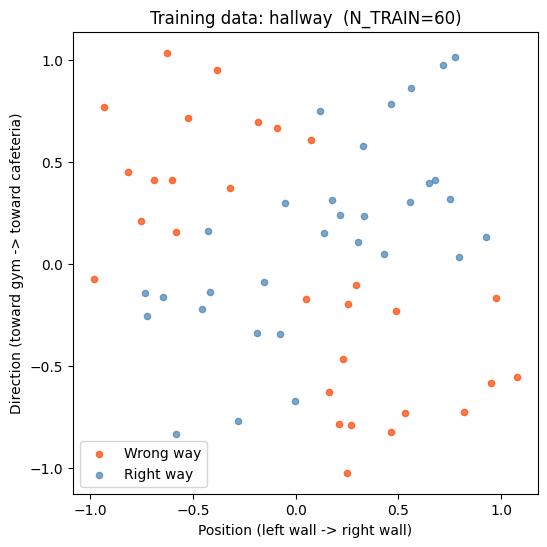

In [3]:
plt.figure(figsize=(6, 6))
ones = y_train[:, 0] == 1
plt.scatter(X_train[ones, 0], X_train[ones, 1], c="orangered", label=CLASS_NAMES[1], s=20, alpha=0.7)
plt.scatter(X_train[~ones, 0], X_train[~ones, 1], c="steelblue", label=CLASS_NAMES[0], s=20, alpha=0.7)
plt.xlabel(AXIS_NAMES[0]); plt.ylabel(AXIS_NAMES[1])
plt.title(f"Training data: {DATASET}  (N_TRAIN={len(y_train)})")
plt.legend()
plt.show()

In [4]:
def quick_train(X, y, n_hidden, epochs=3000, seed=0):
    #Minimal training loop, same math as Section 2 (defined here so this check can run early)
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 1, (X.shape[1], n_hidden)) * np.sqrt(2 / X.shape[1]); b1 = np.zeros((1, n_hidden))
    W2 = rng.normal(0, 1, (n_hidden, 1)) * np.sqrt(1 / n_hidden); b2 = np.zeros((1, 1))
    for _ in range(epochs):
        Z1 = X @ W1 + b1; A1 = np.maximum(0, Z1)
        A2 = 1 / (1 + np.exp(-np.clip(A1 @ W2 + b2, -500, 500)))
        dZ2 = (A2 - y) / len(y); dZ1 = (dZ2 @ W2.T) * (Z1 > 0)
        W2 -= 0.5 * A1.T @ dZ2; b2 -= 0.5 * dZ2.sum(0, keepdims=True)
        W1 -= 0.5 * X.T @ dZ1;  b1 -= 0.5 * dZ1.sum(0, keepdims=True)
    return lambda Xn: 1 / (1 + np.exp(-np.clip(np.maximum(0, Xn @ W1 + b1) @ W2 + b2, -500, 500)))

X_chk, y_chk = build_synthetic(2000, seed=BASE_SEED + 10)
y_chk = y_chk.reshape(-1, 1).astype(float)
X_chk_val, y_chk_val = build_synthetic(1000, seed=BASE_SEED + 11)
y_chk_val = y_chk_val.reshape(-1, 1).astype(float)

baseline = max(y_chk_val.mean(), 1 - y_chk_val.mean())
acc_1 = ((quick_train(X_chk, y_chk, 1)(X_chk_val) > 0.5) == y_chk_val).mean()

print(f"Always guessing the most common class: {baseline:.3f}")
print(f"1 hidden neuron  (one straight cut):   {acc_1:.3f}")
print(f"\nOne straight cut beats guessing by {acc_1 - baseline:+.3f}.")
print("Look at your data plot: what would the boundary need to do that one straight cut can't?")

Always guessing the most common class: 0.526
1 hidden neuron  (one straight cut):   0.629

One straight cut beats guessing by +0.103.
Look at your data plot: what would the boundary need to do that one straight cut can't?


### 📝 DESIGN LOG 1: Go to your word document and answer your questions


## 2. The network (run, don't edit)

This is the same 2-layer network from the warm/cool lab:
inputs &rarr; hidden layer (ReLU) &rarr; 1 output (sigmoid).

One change: `train` now checks the **validation set every 50 epochs**, not just at the end,
so you can watch training and validation accuracy side by side.

In [5]:
#Sets up ReLU activation function
def relu(z):
    return np.maximum(0, z)

#Sets up Sigmoid activation function (clip keeps np.exp from overflowing on extreme values)
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

#Randomly generates the starting values for all weights and biases in the neural network
def init_params(n_in, n_hidden, n_out, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, 1, (n_in, n_hidden)) * np.sqrt(2 / n_in)   # He init, good for ReLU
    b1 = np.zeros((1, n_hidden))
    W2 = rng.normal(0, 1, (n_hidden, n_out)) * np.sqrt(1 / n_hidden)
    b2 = np.zeros((1, n_out))
    return W1, b1, W2, b2

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

def bce_loss(A2, y, eps=1e-9):
    return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))

def backward(X, y, Z1, A1, A2, W2):
    n = X.shape[0]
    dZ2 = (A2 - y) / n
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * (Z1 > 0)     # ReLU derivative: 1 where Z1>0, else 0
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2

def accuracy(X, y, W1, b1, W2, b2):
    _, _, _, A2 = forward(X, W1, b1, W2, b2)
    return ((A2 > 0.5).astype(float) == y).mean()

def train(X, y, n_hidden, lr=0.5, epochs=3000, seed=42, X_val=None, y_val=None):
    W1, b1, W2, b2 = init_params(X.shape[1], n_hidden, y.shape[1], seed=seed)
    #history holds (epoch, train_loss, train_acc, val_loss, val_acc) every 50 epochs
    history = []
    for epoch in range(epochs):
        Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(X, y, Z1, A1, A2, W2)
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
        if X_val is not None and epoch % 50 == 0:
            train_loss = bce_loss(A2, y)
            train_acc = ((A2 > 0.5).astype(float) == y).mean()
            _, _, _, A2_val = forward(X_val, W1, b1, W2, b2)
            val_loss = bce_loss(A2_val, y_val)
            val_acc = ((A2_val > 0.5).astype(float) == y_val).mean()
            history.append((epoch, train_loss, train_acc, val_loss, val_acc))
    return W1, b1, W2, b2, history

## 2b. How hidden neurons build a boundary

Each hidden neuron draws **one straight line** across your data. On one side of its line the
neuron is off (ReLU outputs 0); on the other side it turns on. The output neuron combines them,
so the final boundary is made of straight pieces, and it can **only bend where it crosses one of
the neurons' lines**.

Below, networks of different sizes learn a simple shape: a square "target zone" in a room (green
outline). Each dashed line is one hidden neuron. Watch how the boundary changes as lines are added.

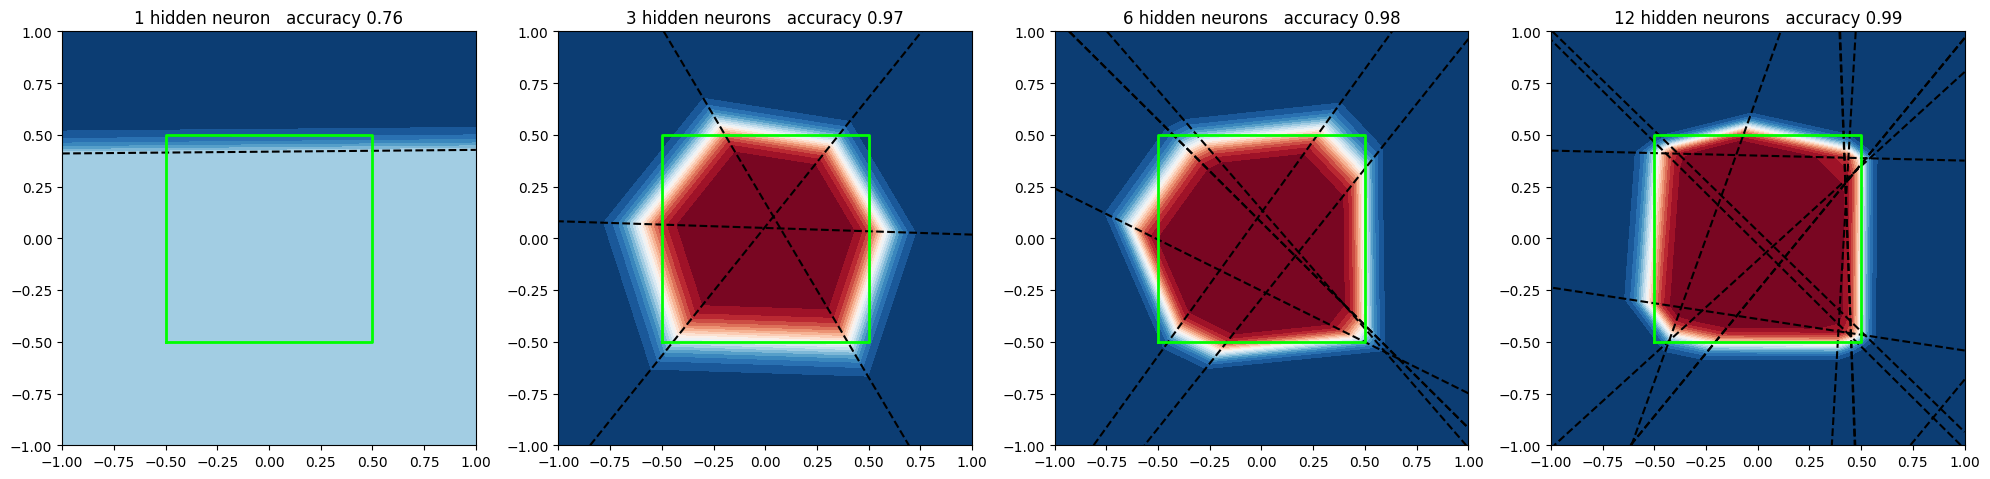

In [6]:
demo_rng = np.random.default_rng(0)
X_demo = demo_rng.uniform(-1, 1, (1000, 2))
#Label 1 = inside the square target zone
y_demo = ((np.abs(X_demo[:, 0]) < 0.5) & (np.abs(X_demo[:, 1]) < 0.5)).astype(float).reshape(-1, 1)

g = np.linspace(-1, 1, 200)
G0, G1 = np.meshgrid(g, g)
grid = np.stack([G0.ravel(), G1.ravel()], axis=1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, n in zip(axes, [1, 3, 6, 12]):
    W1d, b1d, W2d, b2d, _ = train(X_demo, y_demo, n, epochs=3000, seed=1)
    _, _, _, preds = forward(grid, W1d, b1d, W2d, b2d)
    ax.contourf(G0, G1, preds.reshape(G0.shape), levels=np.linspace(0, 1, 21), cmap="RdBu_r")
    #Each hidden neuron's line is where its input (Z1) equals 0
    Z1_grid = grid @ W1d + b1d
    for j in range(n):
        ax.contour(G0, G1, Z1_grid[:, j].reshape(G0.shape), levels=[0],
                   colors="black", linestyles="--", linewidths=1.5)
    ax.plot([-0.5, 0.5, 0.5, -0.5, -0.5], [-0.5, -0.5, 0.5, 0.5, -0.5], color="lime", linewidth=2)
    acc = ((forward(X_demo, W1d, b1d, W2d, b2d)[3] > 0.5) == y_demo).mean()
    ax.set_title(f"{n} hidden neuron{'s' if n > 1 else ''}   accuracy {acc:.2f}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 📝 DESIGN LOG 2: Go to your word document

## 3. Train one network and watch it learn

### 🔽 EDIT ME
Use a value from the range that you predicted, then run this cell **and everything below it**.

In [7]:
N_HIDDEN = 4          # hidden neurons: use a value from the range you predicted

Network: 2 -> 4 -> 1
  Final training accuracy:   0.767
  Final validation accuracy: 0.712
  Gap (train - val):         +0.055
  Best validation accuracy was 0.713 at epoch 1450


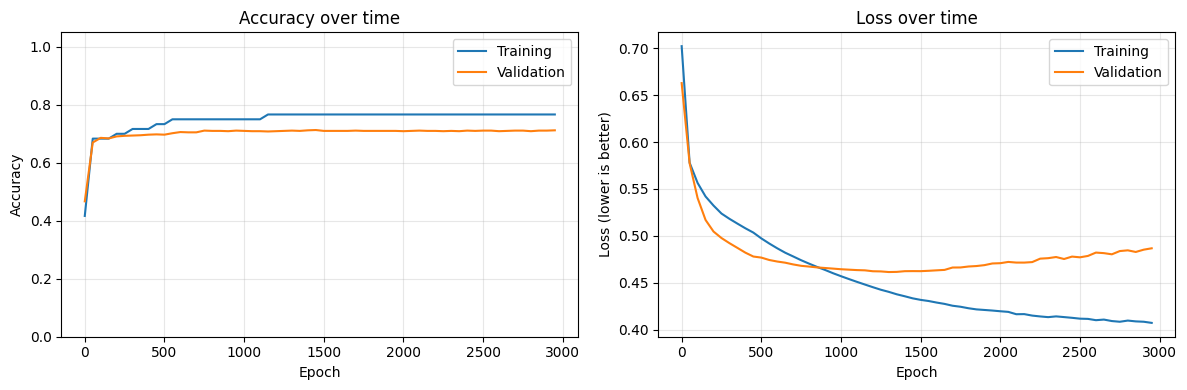

In [8]:
LEARNING_RATE = 0.5   # how big each weight update is
EPOCHS = 3000         # how many times the network sees the whole training set (galaxy may need 6000+)

W1, b1, W2, b2, history = train(X_train, y_train, N_HIDDEN, lr=LEARNING_RATE, epochs=EPOCHS,
                                X_val=X_val, y_val=y_val)
epochs_seen, tr_loss, tr_acc, va_loss, va_acc = map(np.array, zip(*history))

print(f"Network: {N_INPUTS} -> {N_HIDDEN} -> 1")
print(f"  Final training accuracy:   {tr_acc[-1]:.3f}")
print(f"  Final validation accuracy: {va_acc[-1]:.3f}")
print(f"  Gap (train - val):         {tr_acc[-1] - va_acc[-1]:+.3f}")
print(f"  Best validation accuracy was {va_acc.max():.3f} at epoch {epochs_seen[va_acc.argmax()]}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_seen, tr_acc, label="Training")
ax1.plot(epochs_seen, va_acc, label="Validation")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.set_ylim(0, 1.05)
ax1.set_title("Accuracy over time"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_seen, tr_loss, label="Training")
ax2.plot(epochs_seen, va_loss, label="Validation")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss (lower is better)")
ax2.set_title("Loss over time"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### How to read these curves

**What the two lines are.** Every 50 epochs, the notebook checks the network on two sets of data:
- **Training** -- the examples the network is learning from. It sees these over and over.
- **Validation** -- examples the network has *never* trained on.

Think of training accuracy as a score on the practice problems you studied, and validation accuracy as a score on a quiz with new problems. Anyone can ace practice problems by memorizing the answers. Only someone who understands the material does well on the new quiz. **Validation
is the number that tells you whether your network actually learned something.**

**What accuracy and loss measure.**
- **Accuracy** only counts right vs. wrong: did the prediction land on the correct side of 0.5?
- **Loss** also measures *confidence*. A network that says "95% sure it's Wrong way" and is wrong gets penalized much more than one that says "55% sure" and is wrong.

This is why the loss plot often warns you first. A network that is starting to overfit gets *more confident* about its training examples, including the noisy ones. On new data, that extra confidence is misplaced, so validation loss climbs even while validation accuracy barely moves.

**The patterns to look for:**

1. **Both lines climb together and level off near each other** -- the network learned the real pattern. What it learned from the training data also works on new data.

2. **Both lines level off low** -- **underfitting**. The network is too simple to draw the boundary your data needs (or it hasn't trained long enough). "Low" means low compared to what your data allows: check it against the "always guessing" number from the straight-line check. A network barely beating that number hasn't learned much. Note: with `SHAPE_NOISE`, some points from the two classes overlap, and *no* network can get those right. So 100% may not be possible, and leveling off at 90% might be the best anyone can do.

3. **Training keeps improving while validation stalls or gets worse** -- **overfitting**. The network is memorizing individual training examples, including their noise, instead of learning the general pattern. The space between the two lines is called the **gap**, and a gap that keeps growing is the sign. The clearest warning is **validation loss turning upward** while training loss keeps falling. The epoch where validation loss is lowest is roughly when the network was at its best; everything after that point is memorization.

4. **Validation is *higher* than training (a negative gap)** -- this can happen when you use `LABEL_NOISE`. Some training labels were deliberately flipped to the wrong answer, and training accuracy is scored against those wrong labels. A network that learned the real pattern will "disagree" with the flipped labels and get marked wrong on them, while validation (whose labels are all correct) scores it fairly. So a negative gap is a **good** sign: your network is ignoring the bad labels instead of memorizing them. If you make the network bigger and the gap turns positive, it has started memorizing the noise.

**Quick checklist when you look at your curves:**
- Where does validation accuracy level off, and how does that compare to "always guessing"?
- How big is the gap between training and validation at the end?
- Does validation loss ever turn upward? If so, at about what epoch?

## 4. See what the network learned

The background shows what the network predicts everywhere. The dots are your **training** examples.
An overfit network often draws strange islands or wiggles to capture individual noisy dots.

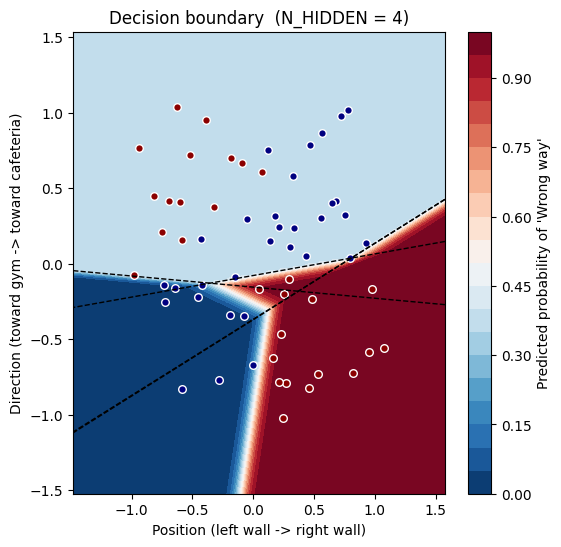

In [9]:
def plot_decision_boundary(W1, b1, W2, b2, n_hidden, ax):
    if N_INPUTS == 2:
        pad = 0.5
        x0 = np.linspace(X_train[:, 0].min() - pad, X_train[:, 0].max() + pad, 200)
        x1 = np.linspace(X_train[:, 1].min() - pad, X_train[:, 1].max() + pad, 200)
        G0, G1 = np.meshgrid(x0, x1)
        grid = np.stack([G0.ravel(), G1.ravel()], axis=1)
        _, _, _, preds = forward(grid, W1, b1, W2, b2)
        cs = ax.contourf(G0, G1, preds.reshape(G0.shape), levels=np.linspace(0, 1, 21), cmap="RdBu_r")
        Z1_grid = grid @ W1 + b1
        for j in range(n_hidden):
            ax.contour(G0, G1, Z1_grid[:, j].reshape(G0.shape), levels=[0],
                       colors="black", linestyles="--", linewidths=1)
        ones = y_train[:, 0] == 1
        ax.scatter(X_train[ones, 0], X_train[ones, 1], c="darkred", edgecolor="white", s=30)
        ax.scatter(X_train[~ones, 0], X_train[~ones, 1], c="navy", edgecolor="white", s=30)
        ax.set_xlabel(AXIS_NAMES[0]); ax.set_ylabel(AXIS_NAMES[1])
    else:
        ax.text(0.5, 0.5, f"Can't draw a boundary\nwith {N_INPUTS} inputs.\nUse the curves instead.",
                ha="center", va="center", fontsize=14)
        ax.axis("off")
        return None
    ax.set_title(f"Decision boundary  (N_HIDDEN = {n_hidden})")
    return cs

fig, ax = plt.subplots(figsize=(6, 6))
cs = plot_decision_boundary(W1, b1, W2, b2, N_HIDDEN, ax)
if cs is not None:
    plt.colorbar(cs, label=f"Predicted probability of '{CLASS_NAMES[1]}'")
plt.show()

### 📝 DESIGN LOG 3: Go to your word document


## 5. Which mistakes is it making? (validation set)

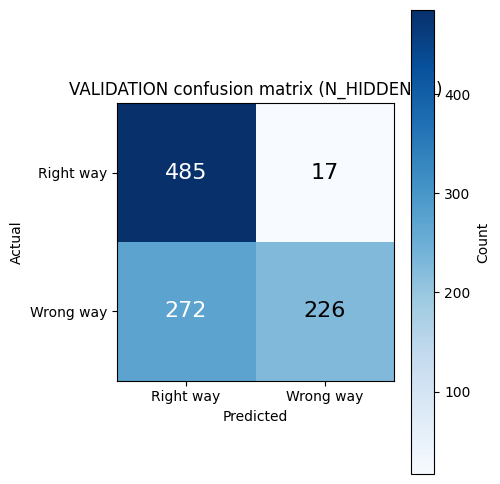

False positives (actually Right way, predicted Wrong way): 17
False negatives (actually Wrong way, predicted Right way): 272


In [10]:
def confusion_matrix(y_true, y_pred):
    y_true, y_pred = y_true[:, 0], y_pred[:, 0]
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])  # rows = actual, cols = predicted

def show_confusion(cm, title, cmap):
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.colorbar(im, label="Count")
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f"False positives (actually {CLASS_NAMES[0]}, predicted {CLASS_NAMES[1]}): {fp}")
    print(f"False negatives (actually {CLASS_NAMES[1]}, predicted {CLASS_NAMES[0]}): {fn}")

_, _, _, A2_val = forward(X_val, W1, b1, W2, b2)
show_confusion(confusion_matrix(y_val, (A2_val > 0.5).astype(float)),
               f"VALIDATION confusion matrix (N_HIDDEN={N_HIDDEN})", "Blues")

### 📝 DESIGN LOG 4: Go to your word document

## 6. Choose your network size with evidence

This trains a fresh network at every size in the list, **3 times each** with different random
starting weights, and averages the results. With small datasets, a single run can be lucky or
unlucky, so the average is more trustworthy.

This can take a minute or two.

N_HIDDEN=  1   train=0.622   val=0.654   gap=-0.031   (val range 0.646-0.664)


N_HIDDEN=  2   train=0.706   val=0.725   gap=-0.019   (val range 0.650-0.817)


N_HIDDEN=  4   train=0.961   val=0.886   gap=+0.075   (val range 0.883-0.889)


N_HIDDEN=  8   train=0.956   val=0.890   gap=+0.066   (val range 0.887-0.892)


N_HIDDEN= 16   train=0.989   val=0.890   gap=+0.099   (val range 0.889-0.890)


N_HIDDEN= 32   train=0.994   val=0.891   gap=+0.103   (val range 0.889-0.895)


N_HIDDEN= 64   train=1.000   val=0.894   gap=+0.106   (val range 0.893-0.895)


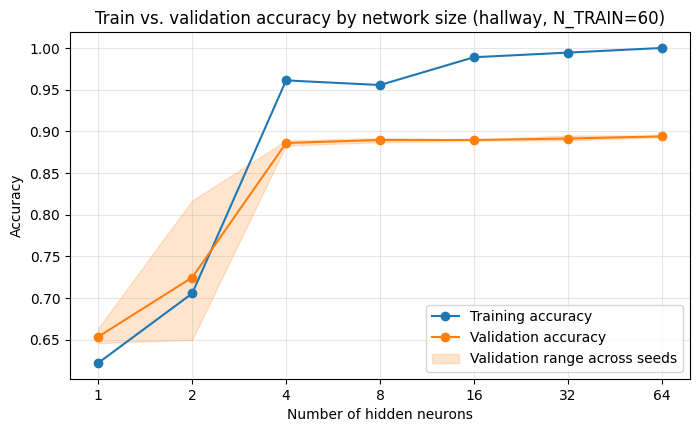

In [11]:
SIZES_TO_TEST = [1, 2, 4, 8, 16, 32, 64]   # 🔽 EDIT ME if you want different sizes
SEEDS = [1, 2, 3]

results = []
for n_hidden in SIZES_TO_TEST:
    tr, va = [], []
    for seed in SEEDS:
        params = train(X_train, y_train, n_hidden, lr=LEARNING_RATE, epochs=EPOCHS, seed=seed)[:4]
        tr.append(accuracy(X_train, y_train, *params))
        va.append(accuracy(X_val, y_val, *params))
    results.append((n_hidden, np.mean(tr), np.mean(va), np.min(va), np.max(va)))
    print(f"N_HIDDEN={n_hidden:3d}   train={np.mean(tr):.3f}   val={np.mean(va):.3f}"
          f"   gap={np.mean(tr) - np.mean(va):+.3f}   (val range {np.min(va):.3f}-{np.max(va):.3f})")

sizes, tr_mean, va_mean, va_min, va_max = map(np.array, zip(*results))
plt.figure(figsize=(8, 4.5))
plt.plot(sizes, tr_mean, marker="o", label="Training accuracy")
plt.plot(sizes, va_mean, marker="o", label="Validation accuracy")
plt.fill_between(sizes, va_min, va_max, alpha=0.2, color="tab:orange", label="Validation range across seeds")
plt.xscale("log", base=2)
plt.xticks(sizes, [str(s) for s in sizes])
plt.xlabel("Number of hidden neurons"); plt.ylabel("Accuracy")
plt.title(f"Train vs. validation accuracy by network size ({DATASET}, N_TRAIN={len(y_train)})")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Compaire Two Networks Directly

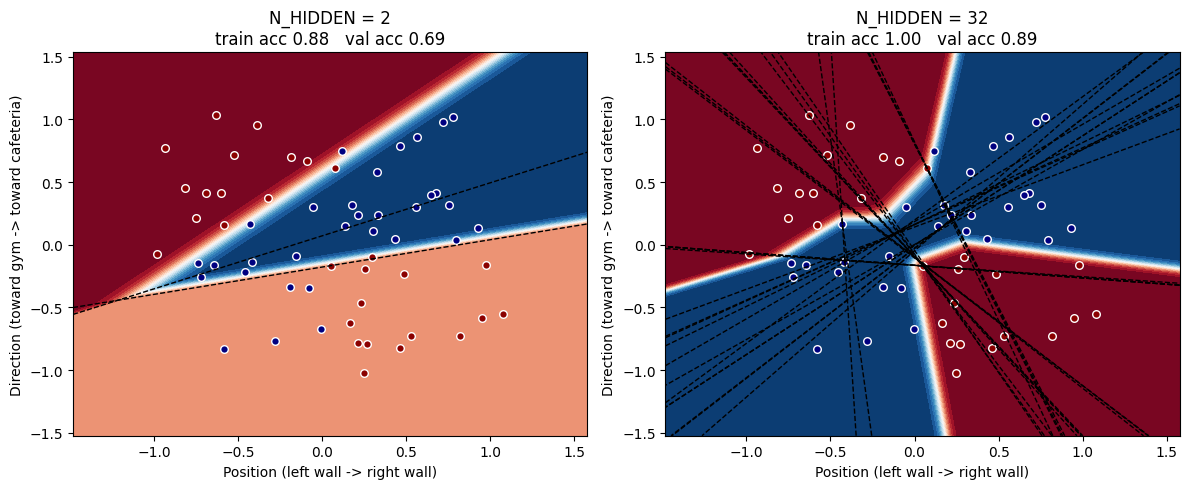

In [12]:
COMPARE_SIZES = [2, 32]   # 🔽 EDIT ME: try different pairs

fig, axes = plt.subplots(1, len(COMPARE_SIZES), figsize=(6 * len(COMPARE_SIZES), 5))
for ax, size in zip(np.atleast_1d(axes), COMPARE_SIZES):
    params = train(X_train, y_train, size, lr=LEARNING_RATE, epochs=EPOCHS)[:4]
    plot_decision_boundary(*params, size, ax)
    ax.set_title(f"N_HIDDEN = {size}\ntrain acc {accuracy(X_train, y_train, *params):.2f}   "
                 f"val acc {accuracy(X_val, y_val, *params):.2f}")
plt.tight_layout()
plt.show()

### 📝 DESIGN LOG 5: Choosing your structure


## 7. Final evaluation: the test set (run ONCE)

Set `FINAL_N_HIDDEN` to the size you chose in Design Log 3, then run this cell **one time**.

⚠️ If you change your design after seeing this result, the test set is no longer a fair test,
and you must say so in Design Log 5.

FINAL network: 2 -> 8 -> 1   (hallway, N_TRAIN=60, label noise 0%)
  Validation accuracy: 0.894
  TEST accuracy:       0.905

  VERIFICATION CODE: 37C5D7E1   <- copy this into Design Log 5


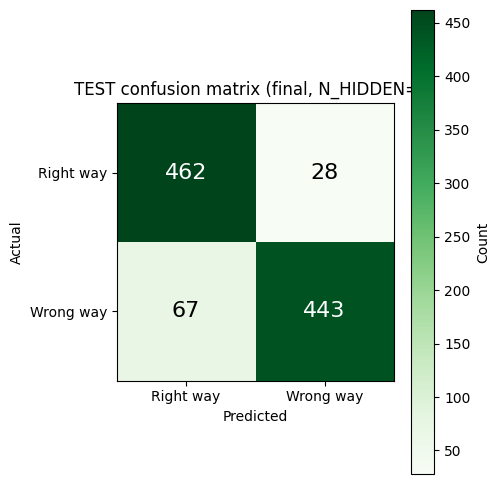

False positives (actually Right way, predicted Wrong way): 28
False negatives (actually Wrong way, predicted Right way): 67


In [13]:
FINAL_N_HIDDEN = 8   # 🔽 EDIT ME: your choice from Design Log 3

W1_f, b1_f, W2_f, b2_f, _ = train(X_train, y_train, FINAL_N_HIDDEN, lr=LEARNING_RATE, epochs=EPOCHS)
test_acc = accuracy(X_test, y_test, W1_f, b1_f, W2_f, b2_f)
val_acc_final = accuracy(X_val, y_val, W1_f, b1_f, W2_f, b2_f)

print(f"FINAL network: {N_INPUTS} -> {FINAL_N_HIDDEN} -> 1   ({DATASET}, N_TRAIN={len(y_train)}, label noise {LABEL_NOISE:.0%})")
print(f"  Validation accuracy: {val_acc_final:.3f}")
print(f"  TEST accuracy:       {test_acc:.3f}")

#Verification code: built from your ID, every setting, and your results. Your teacher can re-run
#your notebook with the same ID and settings and should get exactly the same code.
record = (f"{STUDENT_ID}|{DATASET}|{N_TRAIN}|{SHAPE_NOISE}|{LABEL_NOISE}|{LEARNING_RATE}|"
          f"{EPOCHS}|{FINAL_N_HIDDEN}|{val_acc_final:.4f}|{test_acc:.4f}")
VERIFICATION_CODE = format(zlib.crc32(record.encode()), "08X")
print(f"\n  VERIFICATION CODE: {VERIFICATION_CODE}   <- copy this into Design Log 5")

_, _, _, A2_test = forward(X_test, W1_f, b1_f, W2_f, b2_f)
show_confusion(confusion_matrix(y_test, (A2_test > 0.5).astype(float)),
               f"TEST confusion matrix (final, N_HIDDEN={FINAL_N_HIDDEN})", "Greens")

### 📝 DESIGN LOG 6: Final design summary

## 8. Experiment: What happens with more data?

Your network was designed with a small training set. In the real world, collecting more data
is often possible but expensive: more hallway footage, more Wi-Fi reports, more sensor readings,
more telescope time. Is it worth it? And would it change your design?

### Before you start
1. **Make a copy of this notebook** and do the experiment in the copy. Your original notebook
   should keep the results your Design Logs are based on.
2. **Do not run Section 7 in the copy.** Your test set result is final.

### 📝 Design Log 7: Prediction

### 🔽 EDIT ME (in your copy)
Change **only** `N_TRAIN` to `2000`. Keep your student ID and every other setting the same.
In the Section 4 comparison cell, keep `COMPARE_SIZES` the same as you used in Design Log 4.
Re-run Sections 1 through 6. (This takes longer than before, up to a minute or two.)

### 📝 DESIGN LOG 8: More data vs. more neurons
Use your original notebook and your experiment copy side by side.


